## Path configuration

In [1]:
from pathlib import Path
import os

PROJECT_NAME = "MALDIAlign"

cwd = Path().resolve()

# Walk upwards until we find the project folder
target = None
for parent in [cwd] + list(cwd.parents):
    if parent.name == PROJECT_NAME:
        target = parent
        break

# If the project folder is found and we are not already there, then change cwd
if target is not None and target != cwd:
    os.chdir(target)

print("Working directory:", os.getcwd())

Working directory: /export/usuarios01/agnavarr/MALDIAlign


## Imports

In [5]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.load_config import load_config
from utils.load_data import load_pkl

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

## Data preparation

### Data loading

In [6]:
cfg = load_config()
driams_pkl = cfg["data"]["DRIAMS_REDUCED_PKL"]

In [7]:
driams = load_pkl(driams_pkl)

In [8]:
data, label, meta = driams["data"], driams["label"], driams["meta"]

In [9]:
meta = pd.DataFrame.from_records(list(meta))

### Filter data and construct final dataset

In [10]:
maskA = np.where(meta["hospital"].values == "DRIAMS_A")[0]
dataA, labelA, metaA = data[maskA], label[maskA], meta.iloc[maskA]

maskD = np.where(meta["hospital"].values == "DRIAMS_D")[0]
dataD, labelD, metaD = data[maskD], label[maskD], meta.iloc[maskD]

In [11]:
# Downsample DRIAMS-A
from sklearn.model_selection import train_test_split

_, dataA_sub, _, labelA_sub, _, metaA_sub = train_test_split(
    dataA,
    labelA,
    metaA,
    test_size=len(dataD),
    random_state=42,
    stratify=labelA)

In [12]:
# Concatenate data and labels
data_final = np.vstack([dataA_sub, dataD])
label_final = np.concatenate([labelA_sub, labelD])
meta_final  = pd.concat([metaA_sub, metaD], ignore_index=True)

In [13]:
species, counts = np.unique(labelA_sub, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 676
Enterococcus_Faecium: 473
Escherichia_Coli: 1940
Klebsiella_Pneumoniae: 1073
Pseudomonas_Aeruginosa: 1290
Staphylococcus_Aureus: 1856


In [14]:
species, counts = np.unique(labelD, return_counts=True)
for sp, n in zip(species, counts):
    print(f"{sp}: {n}")

Enterobacter_cloacae_complex: 437
Enterococcus_Faecium: 171
Escherichia_Coli: 2013
Klebsiella_Pneumoniae: 2151
Pseudomonas_Aeruginosa: 362
Staphylococcus_Aureus: 2174


### Construct dataloaders

In [15]:
X_train, X_val, y_train, y_val, meta_train, meta_val = train_test_split(
    data_final, label_final, meta_final,
    test_size=0.2, random_state=42, stratify=label_final
)

In [16]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [17]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor   = torch.tensor(X_val, dtype=torch.float32)

In [18]:
train_dataset = TensorDataset(X_train_tensor, torch.zeros(len(X_train)))
val_dataset   = TensorDataset(X_val_tensor, torch.zeros(len(X_val)))

In [19]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

## VAE

### Architecture

In [65]:
class Encoder(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(input_dim, 512),
        nn.ReLU(),
        nn.Linear(512, 128),
        nn.ReLU()
    )
    self.mu = nn.Linear(128, latent_dim)
    self.logvar = nn.Linear(128, latent_dim)

  def forward(self, x):
    hidden_rep = self.net(x)
    mu = self.mu(hidden_rep)
    logvar = self.logvar(hidden_rep)
    logvar = torch.clamp(logvar, -6, 6)
    return mu, logvar

In [66]:
class Decoder(nn.Module):
  def __init__(self, latent_dim, output_dim):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(latent_dim, 128),
        nn.ReLU(),
        nn.Linear(128, 512),
        nn.ReLU(),
        nn.Linear(512, output_dim)
    )

  def forward(self, z):
    return self.net(z)

In [67]:
class VAE(nn.Module):
  def __init__(self, input_dim, latent_dim):
    super().__init__()
    self.encoder = Encoder(input_dim, latent_dim)
    self.decoder = Decoder(latent_dim, input_dim)

  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = self.reparameterize(mu, logvar)
    x_recon = self.decoder(z)
    return x_recon, mu, logvar

In [68]:
class VAE_Extended(VAE):
    def __init__(self, input_dim, latent_dim, lr=1e-3, epochs=100, annealing_epochs=50):
      super().__init__(input_dim, latent_dim)

      self.lr = lr
      self.epochs = epochs
      self.annealing_epochs = annealing_epochs

      self.optimizer = optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-5)
      self.criterion = nn.MSELoss()

      self.loss_during_training = []
      self.reconstruc_during_training = []
      self.KL_during_training = []

    def loss_function(self, x, x_recon, mu, logvar, beta):
      recon_loss = self.criterion(x_recon, x)
      kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
      total_loss = recon_loss + beta * kl_loss
      return total_loss, recon_loss, kl_loss

    def trainloop(self, trainloader, validloader, device):
      self.to(device)

      for epoch in range(self.epochs):
        beta = min(1.0, (epoch + 1) / self.annealing_epochs)

        # TRAIN
        self.train()
        total_loss, total_recon, total_kl = 0, 0, 0
        for x, _ in trainloader:
          x = x.to(device)
          self.optimizer.zero_grad()
          x_recon, mu, logvar = self.forward(x)
          loss, recon, kl = self.loss_function(x, x_recon, mu, logvar, beta=beta)
          loss.backward()
          self.optimizer.step()
          total_loss += loss.item()
          total_recon += recon.item()
          total_kl += kl.item()

        train_loss = total_loss / len(trainloader)
        train_recon = total_recon / len(trainloader)
        train_kl = total_kl / len(trainloader)

        # VALIDATION
        self.eval()
        val_loss, val_recon, val_kl = 0.0, 0.0, 0.0

        with torch.no_grad():
          for x, _ in validloader:
            x = x.to(device)
            x_recon, mu, logvar = self.forward(x)
            loss, recon, kl = self.loss_function(x, x_recon, mu, logvar, beta=beta)
            val_loss += loss.item()
            val_recon += recon.item()
            val_kl += kl.item()

        val_loss /= len(validloader)
        val_recon /= len(validloader)
        val_kl /= len(validloader)

        if (epoch+1) % 5 == 0:
          print(f"Epoch {epoch+1}/{self.epochs} | "
                f"[Train] Loss: {train_loss:.4f} | Recon: {train_recon:.4f} | KL: {train_kl:.4f} || "
                f"[Val] Loss: {val_loss:.4f} | Recon: {val_recon:.4f} | KL: {val_kl:.4f}")

        self.loss_during_training.append((train_loss, val_loss))
        self.reconstruc_during_training.append((train_recon, val_recon))
        self.KL_during_training.append((train_kl, val_kl))

### Training

In [69]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [70]:
my_vae = VAE_Extended(input_dim=X_train.shape[1], latent_dim=64, lr=1e-4, epochs=100, annealing_epochs=50)
my_vae.trainloop(train_loader, val_loader, device)

Epoch 5/100 | [Train] Loss: 0.8187 | Recon: 0.7877 | KL: 0.3099 || [Val] Loss: 1.0771 | Recon: 1.0498 | KL: 0.2734
Epoch 10/100 | [Train] Loss: 0.8118 | Recon: 0.7698 | KL: 0.2098 || [Val] Loss: 1.0705 | Recon: 1.0272 | KL: 0.2167
Epoch 15/100 | [Train] Loss: 0.8131 | Recon: 0.7593 | KL: 0.1794 || [Val] Loss: 1.0781 | Recon: 1.0292 | KL: 0.1628
Epoch 20/100 | [Train] Loss: 0.8165 | Recon: 0.7572 | KL: 0.1480 || [Val] Loss: 1.0850 | Recon: 1.0290 | KL: 0.1400
Epoch 25/100 | [Train] Loss: 0.8188 | Recon: 0.7547 | KL: 0.1282 || [Val] Loss: 1.0946 | Recon: 1.0356 | KL: 0.1182
Epoch 30/100 | [Train] Loss: 0.8228 | Recon: 0.7535 | KL: 0.1154 || [Val] Loss: 1.0969 | Recon: 1.0297 | KL: 0.1120
Epoch 35/100 | [Train] Loss: 0.8290 | Recon: 0.7554 | KL: 0.1051 || [Val] Loss: 1.1017 | Recon: 1.0303 | KL: 0.1020
Epoch 40/100 | [Train] Loss: 0.8275 | Recon: 0.7507 | KL: 0.0961 || [Val] Loss: 1.1077 | Recon: 1.0335 | KL: 0.0928
Epoch 45/100 | [Train] Loss: 0.8284 | Recon: 0.7455 | KL: 0.0921 || [Val]

### Plot results

In [71]:
train_losses = [t[0] for t in my_vae.loss_during_training]
train_recon = [t[0] for t in my_vae.reconstruc_during_training]
train_kl = [t[0] for t in my_vae.KL_during_training]

val_losses = [t[1] for t in my_vae.loss_during_training]
val_recon = [t[1] for t in my_vae.reconstruc_during_training]
val_kl = [t[1] for t in my_vae.KL_during_training]

epochs = range(1, len(train_losses) + 1)

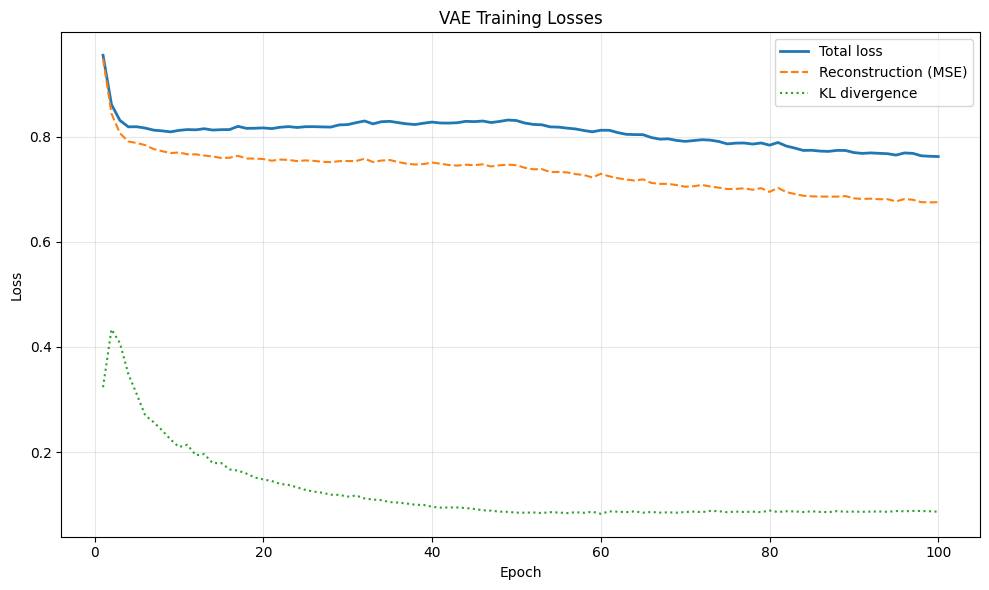

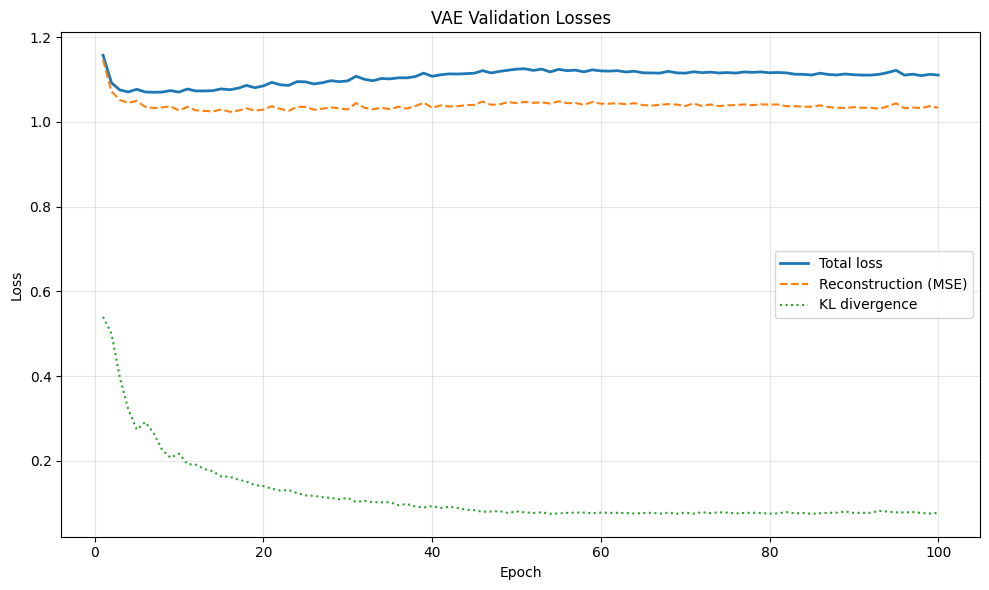

In [72]:
plt.figure(figsize=(10,6))
plt.plot(epochs, train_losses, label='Total loss', linewidth=2)
plt.plot(epochs, train_recon, label='Reconstruction (MSE)', linestyle='--')
plt.plot(epochs, train_kl, label='KL divergence', linestyle=':')
plt.title('VAE Training Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.plot(epochs, val_losses, label='Total loss', linewidth=2)
plt.plot(epochs, val_recon, label='Reconstruction (MSE)', linestyle='--')
plt.plot(epochs, val_kl, label='KL divergence', linestyle=':')
plt.title('VAE Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### t-SNE

In [73]:
X_all = scaler.transform(data_final)
X_all_tensor = torch.tensor(X_all, dtype=torch.float32)

In [74]:
all_dataset = TensorDataset(X_all_tensor, torch.zeros(len(X_all)))
all_loader  = DataLoader(all_dataset, batch_size=256, shuffle=False)

Get latent means for all samples

In [75]:
my_vae.eval()
mus_all = []

with torch.no_grad():
    for xb, _ in all_loader:
        xb = xb.to(device)
        mu, logvar = my_vae.encoder(xb)
        mus_all.append(mu.cpu().numpy())

mus_all = np.concatenate(mus_all, axis=0)  # shape: (N_total, latent_dim)

Global t-SNE

In [76]:
tsne = TSNE(n_components=2, random_state=42)
Z_all = tsne.fit_transform(mus_all)

In [ ]:
tsne_df = pd.DataFrame({
    "x": Z_all[:,0],
    "y": Z_all[:,1],
    "species": label_final,
    "hospital": meta_final["hospital"].values
})

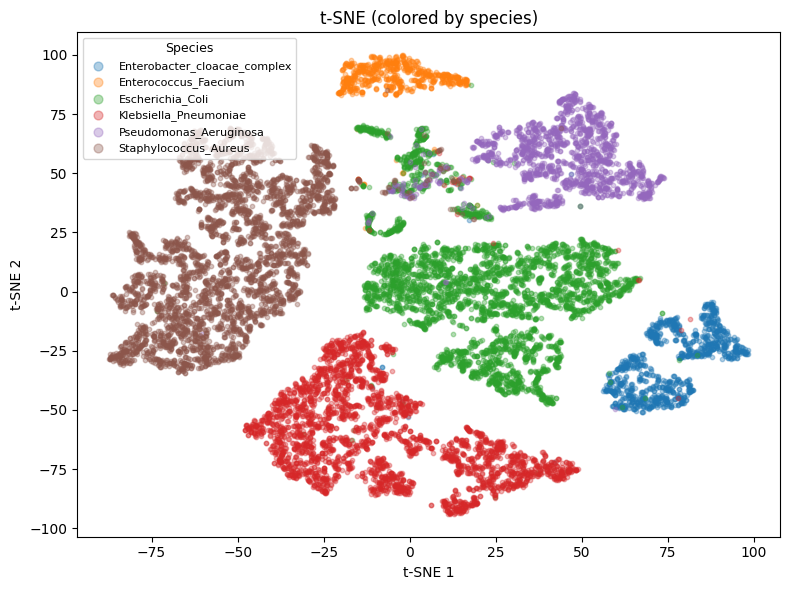

In [87]:
plt.figure(figsize=(8, 6))

for sp in sorted(tsne_df["species"].unique()):
    subset = tsne_df[tsne_df["species"] == sp]
    plt.scatter(
        subset["x"], subset["y"],
        s=10, alpha=0.35, label=sp
    )

plt.title("t-SNE (colored by species)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.legend(
    title="Species",
    markerscale=2,
    loc="upper left",
    frameon=True,
    fontsize=8,
    title_fontsize=9
)

plt.tight_layout()
plt.show()

In [79]:
species_sorted = tsne_df["species"].unique().sort()

In [80]:
hospitals_sorted = tsne_df["hospital"].unique()

In [81]:
colors_hosp = {
    hospitals_sorted[0]: "red",
    hospitals_sorted[1]: "blue"
}

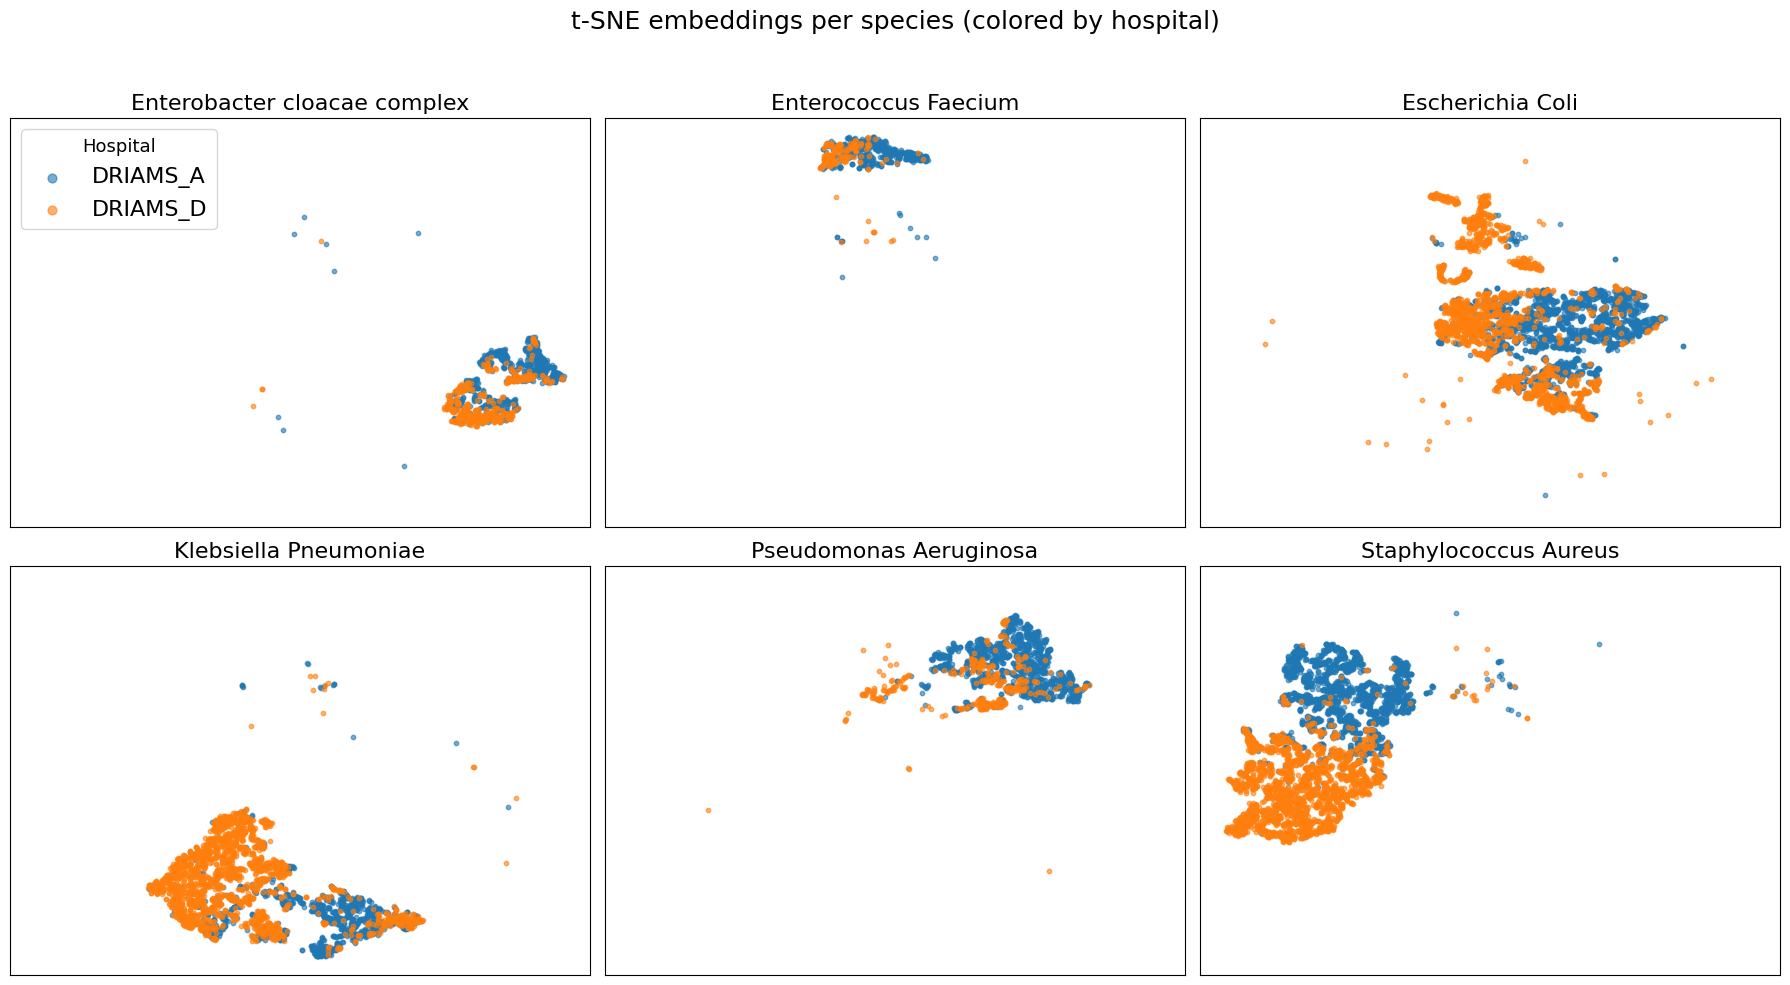

In [100]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    subset = tsne_df[tsne_df["species"] == sp]

    for hosp in hospitals_sorted:
        sub_h = subset[subset["hospital"] == hosp]
        axes[i].scatter(
            sub_h["x"], sub_h["y"],
            s=10,
            alpha=0.6,
            label=hosp if i == 0 else None
        )

    axes[i].set_title(sp.replace("_", " "), fontsize=16)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

axes[0].legend(
    title="Hospital",
    loc="upper left",
    frameon=True,
    fontsize=16,
    title_fontsize=13,
    markerscale=2.0
)

plt.suptitle("t-SNE embeddings per species (colored by hospital)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

t-SNE for each species separately

In [83]:
df_all = pd.DataFrame({
    "species": label_final,
    "hospital": meta_final["hospital"].values
})

for d in range(mus_all.shape[1]):
    df_all[f"z{d}"] = mus_all[:, d]

In [84]:
tsne_results = {}
species_sorted = sorted(np.unique(label_final))

for sp in species_sorted:
    mask = (df_all["species"] == sp)
    X_sp = mus_all[mask]
    tsne = TSNE(
        n_components=2,
        random_state=42,
    )
    X_tsne = tsne.fit_transform(X_sp)
    tsne_results[sp] = {
        "embedding": X_tsne,
        "hospital": df_all.loc[mask, "hospital"].values
    }

Computed independent t-SNE for all species.


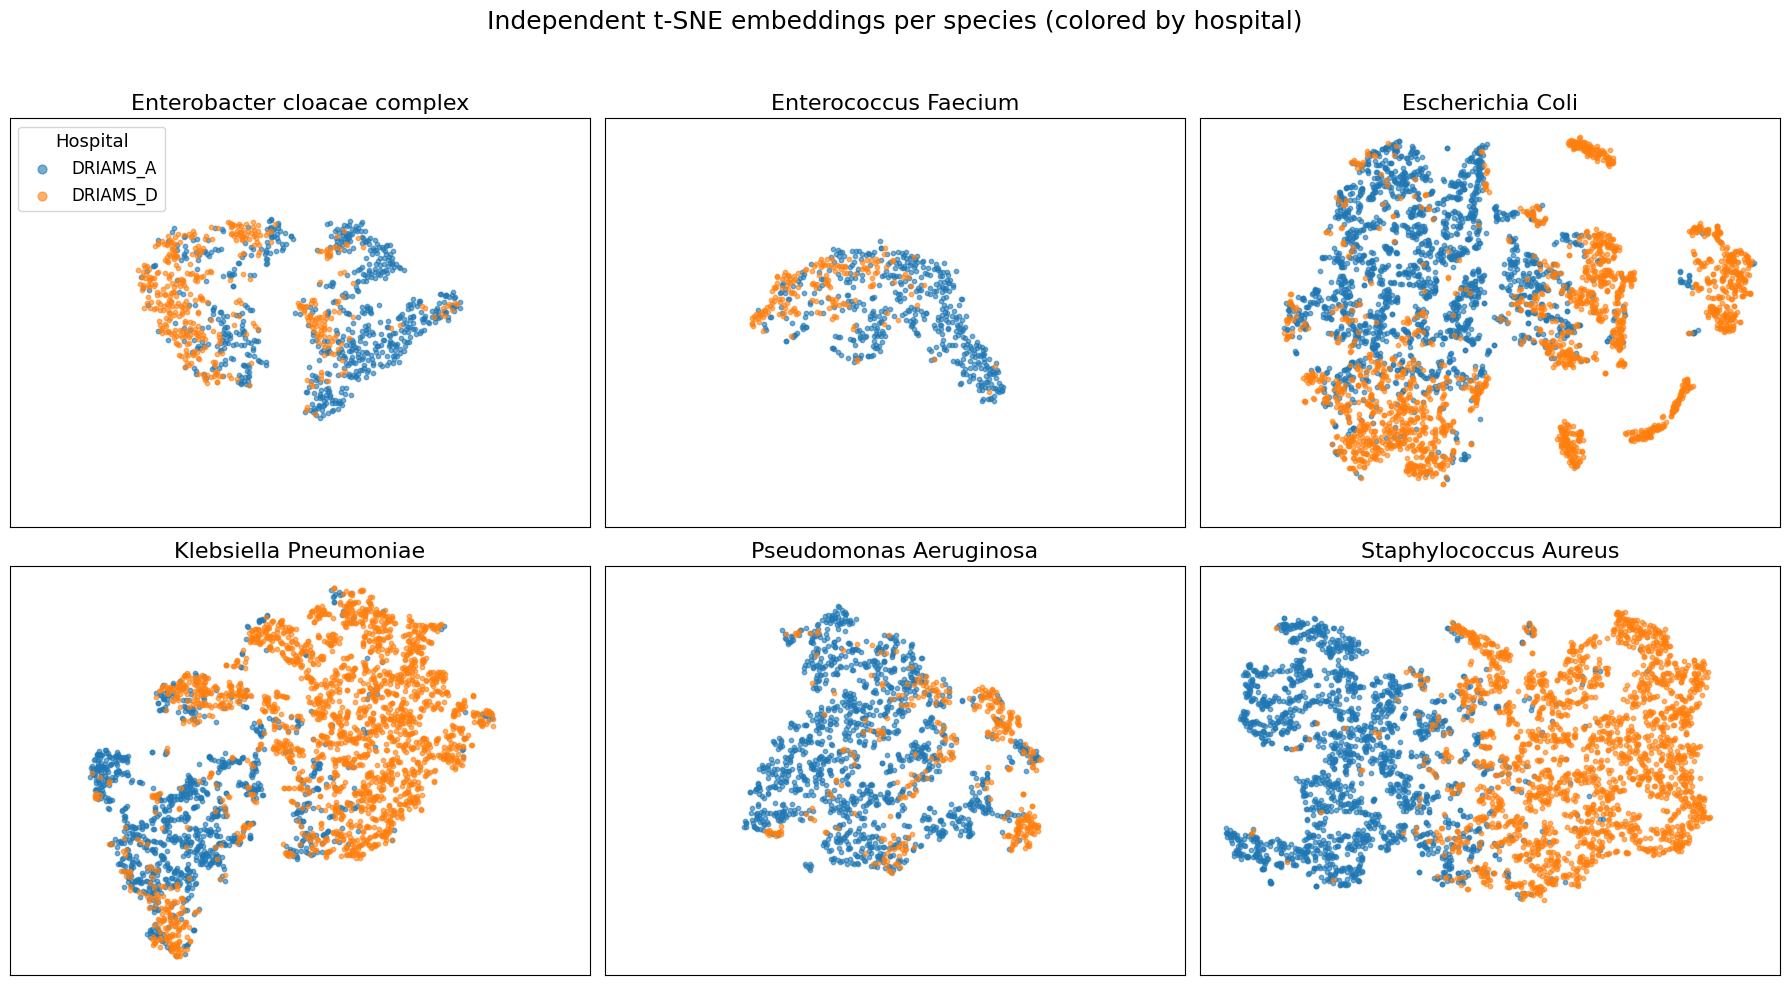

In [101]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, sp in enumerate(species_sorted):
    emb = tsne_results[sp]["embedding"]
    hosp = tsne_results[sp]["hospital"]

    for h in df_all["hospital"].unique():
        idx = (hosp == h)
        axes[i].scatter(
            emb[idx, 0], emb[idx, 1],
            s=10,
            alpha=0.6,
            label=h if i == 0 else None
        )

    axes[i].set_title(sp.replace("_", " "), fontsize=16)
    axes[i].set_xticks([])
    axes[i].set_yticks([])

axes[0].legend(
    title="Hospital",
    loc="upper left",
    frameon=True,
    fontsize=12,
    title_fontsize=13,
    markerscale=2.0
)

plt.suptitle("Independent t-SNE embeddings per species (colored by hospital)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()